%pip install xgboost

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

from xgboost import XGBRegressor

import pickle

In [2]:
df = pd.read_csv("demand_forecasting.csv")

In [3]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [4]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='str')

In [5]:
features=[
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"]

In [6]:
target = "Demand"

In [7]:
X = df[features].copy()

In [8]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [9]:
y = df[target]

In [10]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [11]:
label_encoders = {}
categorical_cols = X.select_dtypes(include = "object").columns

C:\Users\Khushi\AppData\Local\Temp\ipykernel_18296\595275685.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include = "object").columns


In [12]:
categorical_cols

Index(['Category'], dtype='str')

In [13]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [14]:
label_encoders

{'Category': LabelEncoder()}

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [16]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,1
1,80.16,15,117,1,92.02,0
2,62.94,10,247,1,60.08,0
3,87.63,10,139,0,85.19,1
4,54.41,0,152,0,51.63,3
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,4
75996,42.92,5,137,0,40.73,4
75997,17.81,10,197,0,19.41,0
75998,151.72,0,125,0,143.71,2


In [17]:
xgb = XGBRegressor(objective = "reg:squarederror", n_jobs = -1)

In [18]:
param_dict = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

In [19]:
random_search = RandomizedSearchCV(
    estimator = xgb, 
    param_distributions = param_dict,
    n_iter = 25,
    scoring = "neg_mean_absolute_error",
    cv = 3,
    verbose = 1,
    n_jobs = -1
)

In [20]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,25
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [21]:
random_search.best_params_

{'subsample': 0.7,
 'n_estimators': 500,
 'min_child_weight': 1,
 'max_depth': 8,
 'learning_rate': 0.01,
 'colsample_bytree': 1.0}

In [22]:
best_model = random_search.best_estimator_

In [23]:
y_pred = best_model.predict(X_test)

In [24]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 35.563262939453125


In [26]:
best_model.feature_importances_

array([0.04552835, 0.01219602, 0.01171749, 0.71314496, 0.01486885,
       0.20254433], dtype=float32)

In [27]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

In [28]:
feature_importance

Promotion             0.713145
Category              0.202544
Price                 0.045528
Competitor Pricing    0.014869
Discount              0.012196
Inventory Level       0.011717
dtype: float32

<Axes: title={'center': 'Feature Importances'}>

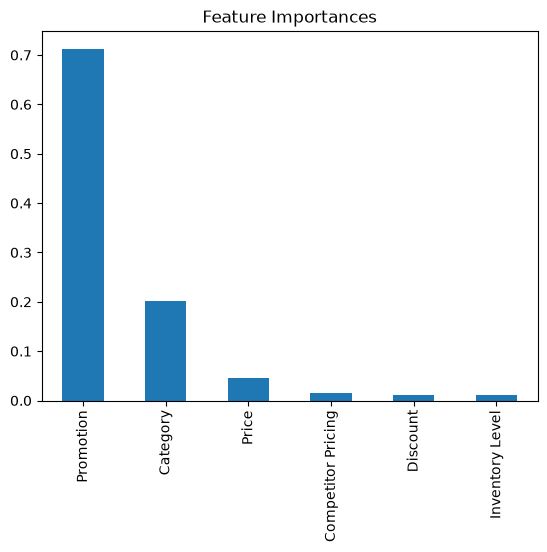

In [29]:
feature_importance.plot(kind = "bar", title = "Feature Importances")

In [30]:
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

In [31]:
with open("xgboost_demand_model.pkl", "wb") as f:
    pickle.dump(best_model, f)